In [1]:
# Run this ONLY if xgboost is not installed
!pip install xgboost

In [2]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost model
from xgboost import XGBClassifier

# Preprocessing
from sklearn.preprocessing import LabelEncoder

In [3]:
# Loading dataset 
df = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\Titanic-Dataset.csv")

# Display first 5 rows to understand structure
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Checking dataset shape
print("Shape:", df.shape)
print("\n-----------------------------------------------------------------------")
# Checking column info (data types + null values)
df.info()
print("\n-----------------------------------------------------------------------")
# Checking missing values
df.isnull().sum()

Shape: (891, 12)

-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

-----------------------------------------------------------------------


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Fill missing Age values using median (robust to outliers)
df['Age']=df['Age'].fillna(df['Age'].median())

# Fill Embarked with most frequent value
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin because too many missing values
df.drop(columns=['Cabin'], inplace=True)

In [6]:
# Removing unnecessary columns
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Convert categorical data into numeric
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [7]:
# Input features
X = df.drop('Survived', axis=1)

# Target variable
y = df['Survived']

In [8]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Checking data sizes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 7)
Test shape: (179, 7)


In [9]:
# Creating XGBoost classifier
# n_estimators = number of trees
# max_depth = depth of each tree
# learning_rate = how fast model learns

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Training the model
model.fit(X_train, y_train)

C:\Users\Chinmay Pratap Dalvi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:21:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
# Predicting on test data
y_pred = model.predict(X_test)

Accuracy: 0.8156424581005587

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



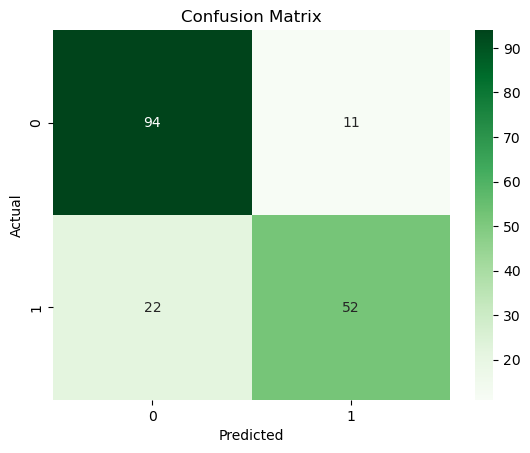

In [11]:
# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

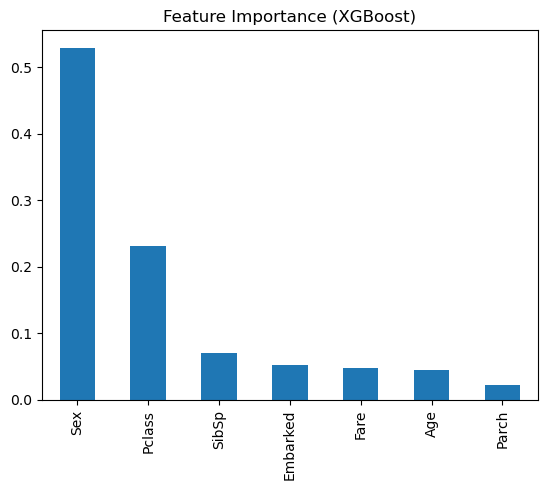

In [12]:
# Extract feature importance from model
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort values
importance = importance.sort_values(ascending=False)

# Plot
importance.plot(kind='bar', title="Feature Importance (XGBoost)")
plt.show()